### Notebook 1: Data Understanding & Exploration

**Objective:** Inspect raw dataset layout, calculate descriptive statistics, check target class balance, explore feature distributions visually, and identify data quality issues.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 300

# Load raw dataset
DATA_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)

# 1. Dataset Shape
print(f"Dataset Shape: {df.shape[0]} rows (customers), {df.shape[1]} columns (features)")

# 2. Data Types & Column Summary
print("\n--- Data Types ---")
print(df.dtypes.value_counts())

# 3. Head and Tail Inspection
print("\n--- First 3 Rows (Head) ---")
display(df.head(3))

print("\n--- Last 3 Rows (Tail) ---")
display(df.tail(3))

Dataset Shape: 7043 rows (customers), 21 columns (features)

--- Data Types ---
str        18
int64       2
float64     1
Name: count, dtype: int64

--- First 3 Rows (Head) ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes



--- Last 3 Rows (Tail) ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [2]:
# 1. Numerical Columns Summary
print("--- Numerical Summary ---")
display(df.describe().T)

# 2. Categorical / Text Columns Summary
print("\n--- Categorical Summary ---")
display(df.describe(include='object').T)

--- Numerical Summary ---


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75



--- Categorical Summary ---


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33836\2685399509.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object').T)


,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


Retained (No) : 5174 (73.46%)
Churned  (Yes): 1869 (26.54%)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33836\485461366.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette=['#1f77b4', '#d62728'])


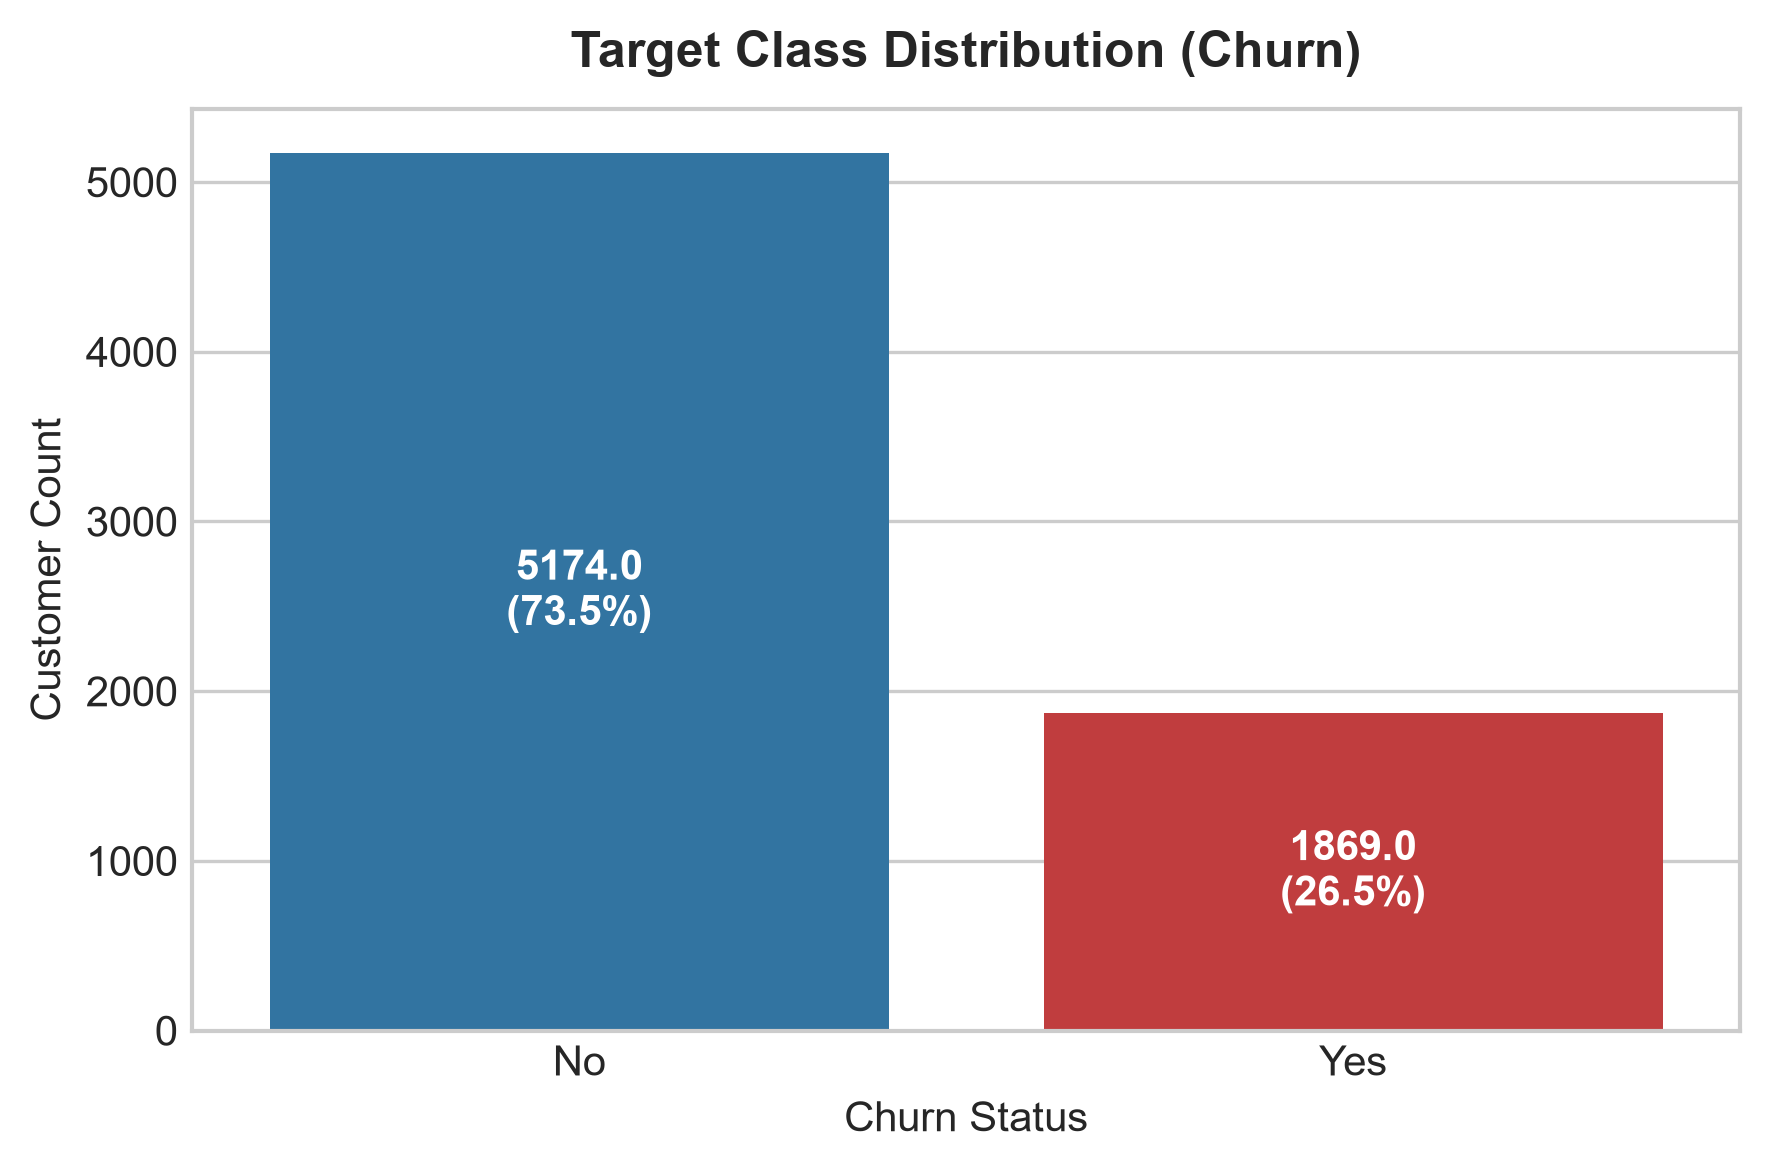

In [3]:
# Count and Percentage Breakdown
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(f"Retained (No) : {churn_counts['No']} ({churn_pct['No']:.2f}%)")
print(f"Churned  (Yes): {churn_counts['Yes']} ({churn_pct['Yes']:.2f}%)")

# Target Distribution Plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette=['#1f77b4', '#d62728'])
plt.title('Target Class Distribution (Churn)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Churn Status')
plt.ylabel('Customer Count')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}\n({height/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../plots/01_churn_distribution.png')
plt.show()